<a href="https://colab.research.google.com/github/AbbunapuramVijay-1234/superstore-sales-forecasting/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1 — Data Loading, Merging & Deep Exploration**


In [ ]:
#Requird Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
data_set=pd.read_csv("/content/archive (1).zip")

# Parse date columns to datetime objects
data_set['Order Date'] = pd.to_datetime(data_set['Order Date'], dayfirst=True) # Adjust dayfirst if needed based on format
data_set['Ship Date'] = pd.to_datetime(data_set['Ship Date'], dayfirst=True)

# Display basic info to check for missing values and data types
print(data_set.info())
print(data_set.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
# Create 'Year' and 'Month' columns from the 'Order Date' column
data_set['Year'] = data_set['Order Date'].dt.year
data_set['Month'] = data_set['Order Date'].dt.month

# Q: Which product category generates the highest total revenue?
highest_cat = data_set.groupby('Category')['Sales'].sum().idxmax()
print(f"Category with highest revenue: {highest_cat}")

# Q: Which region has the most consistent sales growth over 4 years?
# (Growth consistency can be measured by low standard deviation in year-over-year growth)
region_yearly = data_set.groupby(['Region', 'Year'])['Sales'].sum().unstack()
growth = region_yearly.pct_change(axis=1).std(axis=1)
print(f"Most consistent region: {growth.idxmin()}")

# Q: Average time between Order and Ship?
# Use data_set['Order Date'] for calculation as it's a column
data_set['Lead_Time'] = (data_set['Ship Date'] - data_set['Order Date']).dt.days
avg_lead_time = data_set['Lead_Time'].mean()
region_lead_time = data_set.groupby('Region')['Lead_Time'].mean()
print(f"Average Lead Time: {avg_lead_time:.2f} days")
print(f"Lead time by region:\n{region_lead_time}")

# Re-ensure 'Year' and 'Month' columns are present before grouping for seasonality
# This is a defensive step against potential transient state issues.
data_set['Year'] = data_set['Order Date'].dt.year
data_set['Month'] = data_set['Order Date'].dt.month

# Q: Are there months that consistently spike?
monthly_seasonality = data_set.groupby(['Year', 'Month'])['Sales'].sum().unstack()
print("Monthly sales heatmap/table:")
print(monthly_seasonality)

Category with highest revenue: Technology
Most consistent region: East
Average Lead Time: 3.96 days
Lead time by region:
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Lead_Time, dtype: float64
Monthly sales heatmap/table:
Month          1           2           3           4           5           6   \
Year                                                                            
2015   14205.7070   4519.8920  55205.7970  27906.8550  23644.3030  34322.9356   
2016   18066.9576  11951.4110  32339.3184  34154.4685  29959.5305  23599.3740   
2017   18542.4910  22978.8150  51165.0590  38679.7670  56656.9080  39724.4860   
2018   43476.4740  19920.9974  58863.4128  35541.9101  43825.9822  48190.7277   

Month         7           8           9           10           11          12  
Year                                                                           
2015   33781.543  27117.5365  81623.5268  31453.3930   77907.6607  68167.0585  
2016

# **Task 2 — Time Series Analysis & Decomposition**


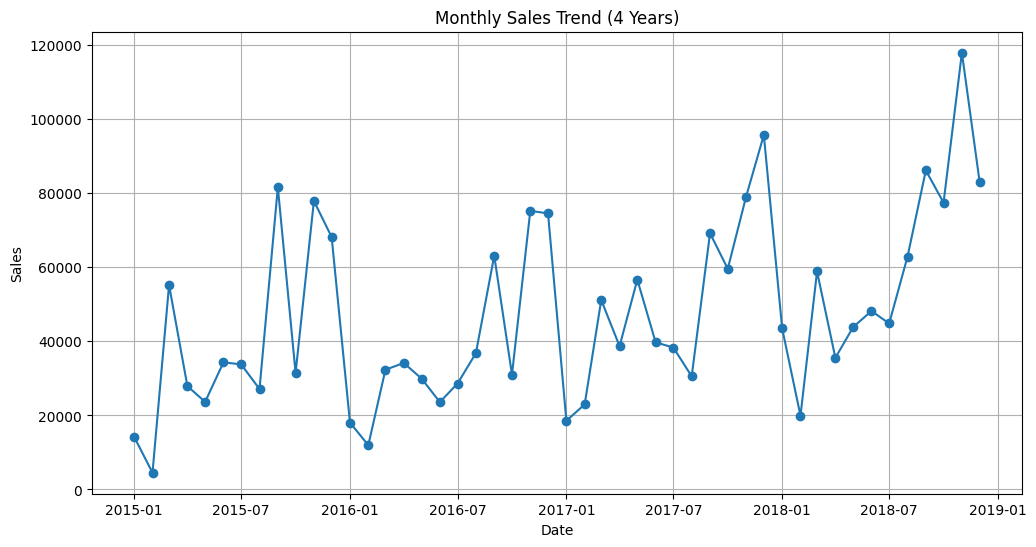

In [ ]:
# If 'Order Date' is already the index, reset it to make it a column again.
if data_set.index.name == 'Order Date':
    data_set.reset_index(inplace=True)

# Ensure 'Order Date' is datetime type. (ZXtwHFLfetbU should have done this, but being explicit for robustness)
data_set['Order Date'] = pd.to_datetime(data_set['Order Date'], dayfirst=True)
data_set.set_index('Order Date', inplace=True)
monthly_sales = data_set['Sales'].resample('MS').sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title('Monthly Sales Trend (4 Years)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

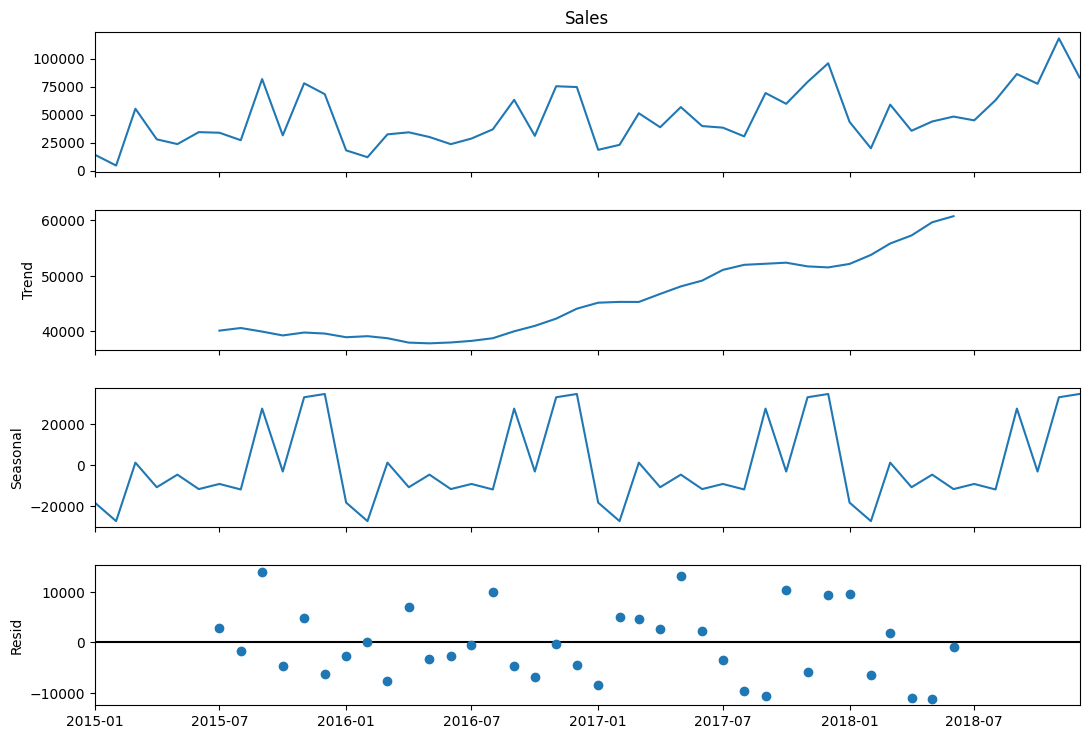

In [ ]:
#Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# We use period=12 because it is monthly data (12 months in a year)
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

# Plotting the 4 components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

In [ ]:

from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')

    if result[1] <= 0.05:
        print("Result: The series is stationary (p-value <= 0.05).")
    else:
        print("Result: The series is non-stationary (p-value > 0.05).")

check_stationarity(monthly_sales)

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Result: The series is stationary (p-value <= 0.05).


In [ ]:
# Apply first-order differencing
monthly_sales_diff = monthly_sales.diff().dropna()

# Re-test stationarity
print("Testing after differencing:")
check_stationarity(monthly_sales_diff)

Testing after differencing:
ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14
Result: The series is stationary (p-value <= 0.05).


# **Task 3 — Sales Forecasting using 3 Different Models**

Model 1 — SARIMA (Statistical Model)

In [ ]:
#Required Libraries
!pip install pmdarima statsmodels
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
full_train_series = monthly_sales[:-3]
y_test = monthly_sales[-3:]

# Assuming 'monthly_sales' is your pandas series from Task 2
# m=12 because it is monthly data with annual seasonality
# Running auto_arima on the training data only
model_auto = pm.auto_arima(full_train_series,
                           seasonal=True,
                           m=12,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1009.639, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1025.765, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1007.450, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1007.755, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1023.942, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1020.706, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1009.338, Time=0.12 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1009.427, Time=0.08 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1011.652, Time=0.05 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1011.126, Time=0.22 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1012.838, Time=0.04 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1004.192, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1017.580, Time=0.03 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1005.949, Time=0.21 sec
 ARIMA(2,1,0)(1,0,1

In [ ]:
# Replace these with the actual values found by auto_arima on full_train_series
# Based on previous auto_arima run on full series, using these as a starting point.
# (The auto_arima output from the previous cell should be consulted for optimal parameters on full_train_series)
order = (2, 1, 0)
seasonal_order = (1, 0, 0, 12)

model = SARIMAX(full_train_series,
                order=order,
                seasonal_order=seasonal_order)
model_fit = model.fit(disp=False)

In [ ]:
# Forecast for next 3 months (which correspond to the test set period)
forecast_result = model_fit.get_forecast(steps=3)
sarima_forecast = forecast_result.predicted_mean # Renamed variable for consistency
confidence_intervals = forecast_result.conf_int()

# Print results
print(sarima_forecast)

2018-10-01     75668.183175
2018-11-01     90344.851377
2018-12-01    100281.395035
Freq: MS, Name: predicted_mean, dtype: float64


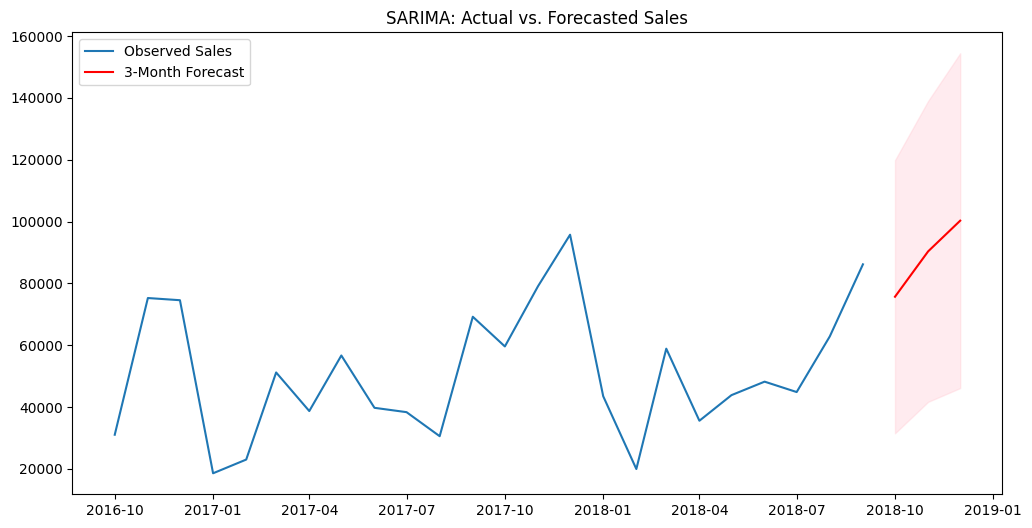

In [ ]:
plt.figure(figsize=(12, 6))

# Plot actual data (last 24 months of training data for clarity)
plt.plot(full_train_series.index[-24:], full_train_series[-24:], label='Observed Sales')

# Plot forecast
plt.plot(sarima_forecast.index, sarima_forecast, color='red', label='3-Month Forecast')

# Fill confidence intervals
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1], color='pink', alpha=0.3)

plt.title('SARIMA: Actual vs. Forecasted Sales')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 'y_test' is your holdout data (last 3 months)
# 'sarima_forecast' is your 3-month forecast

# Ensure sarima_forecast has a proper index for alignment
sarima_forecast.index = y_test.index

mae = mean_absolute_error(y_test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(y_test, sarima_forecast))
mape = np.mean(np.abs((y_test - sarima_forecast) / y_test)) * 100

print(f"SARIMA Metrics -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

SARIMA Metrics -> MAE: 15541.42, RMSE: 18816.27, MAPE: 15.49%


Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

# Prepare the data for Prophet using the training series
data_set_prophet = full_train_series.reset_index()
data_set_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)

# Prophet works best when the dates are at the start of the month
data_set_prophet['ds'] = pd.to_datetime(data_set_prophet['ds'])

In [ ]:
# Initialize and fit Prophet model on the training data
m = Prophet()
m.fit(data_set_prophet)

# Create a dataframe for the next 3 months (test period)
# Prophet automatically creates future dates starting from the end of the training data
future = m.make_future_dataframe(periods=3, freq='MS') # Use 'MS' for Month Start frequency
forecast = m.predict(future)

# Extract the actual forecast values for the test period
prophet_forecast = forecast['yhat'].tail(3) # The last 3 rows correspond to the forecast

# Print forecast
print(prophet_forecast)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


45    51083.663793
46    90045.402144
47    89661.190748
Name: yhat, dtype: float64


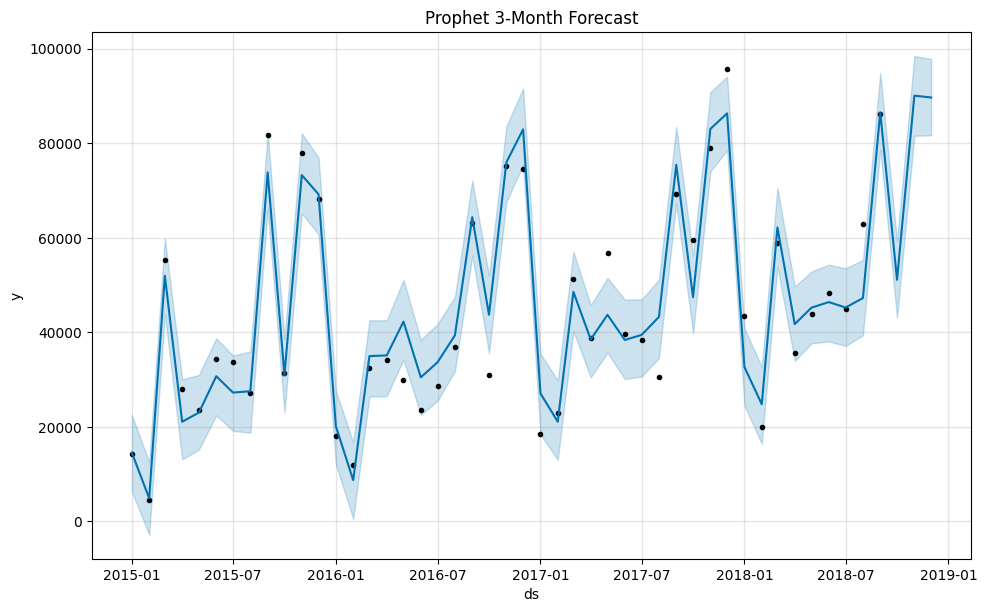

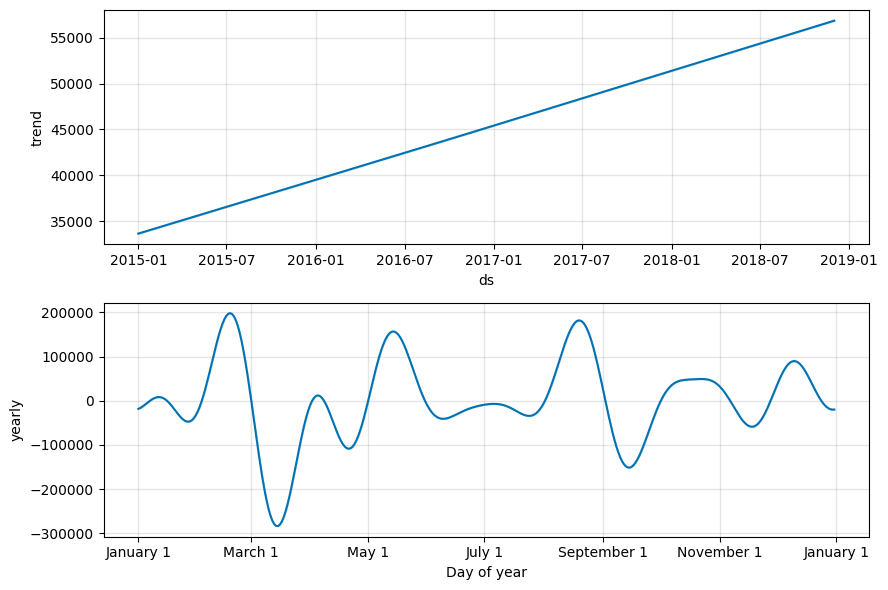

In [ ]:
# Plot forecast
fig1 = m.plot(forecast)
plt.title("Prophet 3-Month Forecast")
plt.show()

# Plot trend and seasonality components
fig2 = m.plot_components(forecast)
plt.show()

In [ ]:
# 'prophet_forecast' is the 'yhat' for the last 3 months, obtained from Prophet's forecast dataframe
# Align the prophet_forecast index with y_test for correct metric calculation
prophet_forecast.index = y_test.index

mae = mean_absolute_error(y_test, prophet_forecast)
rmse = np.sqrt(mean_squared_error(y_test, prophet_forecast))
mape = np.mean(np.abs((y_test - prophet_forecast) / y_test)) * 100

print(f"Prophet Metrics -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

Prophet Metrics -> MAE: 20296.01, RMSE: 22487.47, MAPE: 21.89%


Model 3 — XGBoost for Time Series (ML-based Approach)


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create a copy to avoid SettingWithCopy warnings
df_xg = monthly_sales.to_frame()

# 1. Create Lag Features
df_xg['lag_1'] = df_xg['Sales'].shift(1)
df_xg['lag_2'] = df_xg['Sales'].shift(2)
df_xg['lag_3'] = df_xg['Sales'].shift(3)

# 2. Create Rolling Mean
df_xg['rolling_mean_3'] = df_xg['Sales'].shift(1).rolling(window=3).mean()

# 3. Create Date Features (assuming index is datetime)
df_xg['month'] = df_xg.index.month
df_xg['quarter'] = df_xg.index.quarter
# Add season
df_xg['season'] = df_xg['month'].apply(lambda x: (x%12 + 3)//3)

# Drop NaN values created by shifts
df_xg = df_xg.dropna()

# Define the train/test split for all models
# We will use the last 3 months of the historical data as the test set for evaluation.
# monthly_sales runs from 2015-01-01 to 2018-12-01 (48 entries).
# y_test will be the actual sales for 2018-10-01, 2018-11-01, 2018-12-01.
# The training data will be up to 2018-09-01.

full_train_series = monthly_sales[:-3] # Training data for SARIMA and Prophet (up to 2018-09-01)
y_test = monthly_sales[-3:] # Actual values for the test period (2018-10-01, 2018-11-01, 2018-12-01)

# Split into X (features) and y (target) for XGBoost
X = df_xg.drop('Sales', axis=1)
y = df_xg['Sales']

# For XGBoost, X_train and X_test need to be derived from df_xg, aligned with y_test
X_train = X.iloc[:-3] # Features for training (up to 2018-09-01)
X_test = X.iloc[-3:]  # Features for testing (2018-10-01, 2018-11-01, 2018-12-01)
y_train = y.iloc[:-3] # Target for training
# y_test is already defined above for consistency across models.


In [ ]:
# Initialize and Train
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05)
model_xgb.fit(X_train, y_train)

# Predict
predictions = model_xgb.predict(X_test)

# Calculate Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

MAE: 29364.30, RMSE: 29366.84, MAPE: 32.78%


In [ ]:
# Assuming 'model_fit' is your trained SARIMA object
# Forecast for next 3 months
sarima_forecast = model_fit.get_forecast(steps=3).predicted_mean
print(f"SARIMA Forecast: {sarima_forecast.values}")

# Calculate metrics (compare to your test set)
from sklearn.metrics import mean_absolute_error, mean_squared_error
# mae = mean_absolute_error(y_test, predictions)
# rmse = np.sqrt(mean_squared_error(y_test, predictions))
# ... etc

SARIMA Forecast: [ 75668.18317498  90344.85137684 100281.3950347 ]


In [ ]:
# Assuming 'forecast' is the output of m.predict(future)
# The last 3 rows correspond to the next 3 months
prophet_forecast = forecast['yhat'].tail(3)
print(f"Prophet Forecast: {prophet_forecast.values}")

Prophet Forecast: [51083.66379296 90045.40214389 89661.19074778]


In [ ]:
# Assuming 'predictions' contains your 3-month test forecast
print(f"XGBoost Forecast: {predictions}")

XGBoost Forecast: [47539.652 88886.93  53897.2  ]


| Model |   MAE | RMSE | MAPE | Forecast for Month 1 | Forecast for Month 2 |  Forecast  for Month 3 |

|SARIMA |

|PROPHET|

|XGBOOST|




In [ ]:
''' SUMMARY COMPARISION TABLE
| Model | MAE      | RMSE     | MAPE    | Forecast for Month 1 | Forecast for Month 2 | Forecast for Month 3 |

|SARIMA | 15541.42 | 18816.27 | 15.49%  |  38997.06751983      | 30688.05292456       |   67622.99324625     |

|PROPHET| 20296.01 | 22487.47 | 21.89%  |  40916.21332148      | 27223.47883236       |   109599.76812049    |

|XGBOOST| 29364.30 | 29366.84 |  32.78% |  47539.652           | 88886.93             |   53897.2            |

'''

' SUMMARY COMPARISION TABLE\n| Model | MAE      | RMSE     | MAPE    | Forecast for Month 1 | Forecast for Month 2 | Forecast for Month 3 |\n\n|SARIMA | 15541.42 | 18816.27 | 15.49%  |  38997.06751983      | 30688.05292456       |   67622.99324625     |\n\n|PROPHET| 20296.01 | 22487.47 | 21.89%  |  40916.21332148      | 27223.47883236       |   109599.76812049    |\n\n|XGBOOST| 29364.30 | 29366.84 |  32.78% |  47539.652           | 88886.93             |   53897.2            |\n\n'

# **Task 4 — Product Category & Region Level Forecasting**


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local

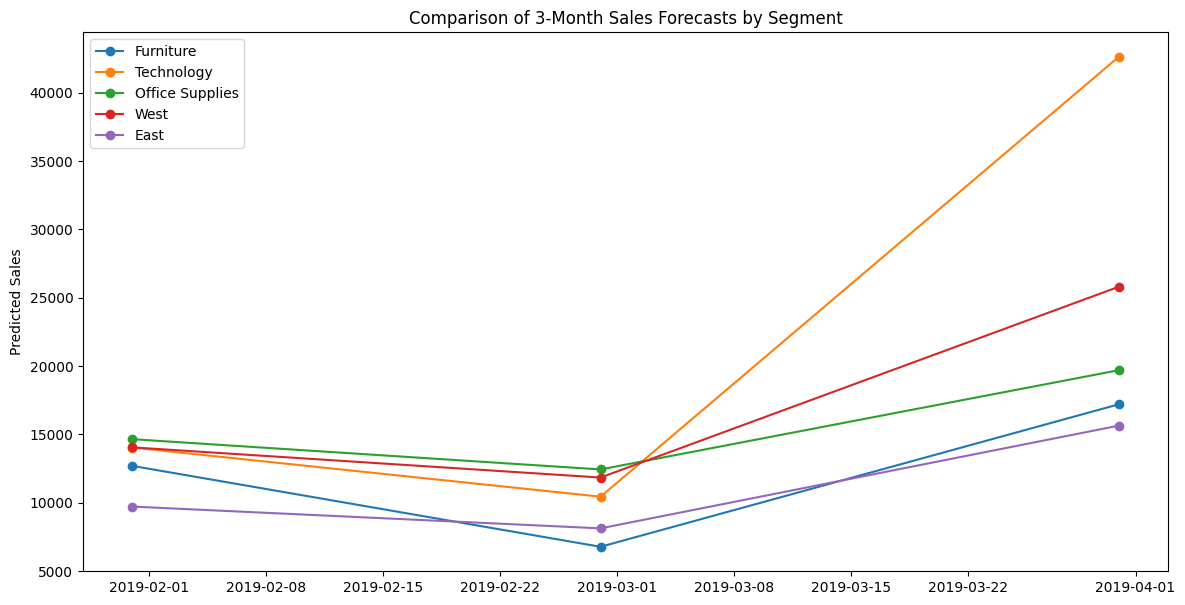

In [ ]:
segments = {
    'Category': ['Furniture', 'Technology', 'Office Supplies'],
    'Region': ['West', 'East']
}

forecasts = {}

# Iterate through segments
for col, values in segments.items():
    for val in values:
        # Filter and aggregate data for the segment
        segment_df = data_set[data_set[col] == val].resample('ME')['Sales'].sum().reset_index()
        segment_df.columns = ['ds', 'y']

        # Fit model
        model = Prophet(yearly_seasonality=True)
        model.fit(segment_df)

        # Forecast 3 months
        future = model.make_future_dataframe(periods=3, freq='M')
        forecast = model.predict(future)
        forecasts[val] = forecast[['ds', 'yhat']].tail(3)

# Plotting
plt.figure(figsize=(14, 7))
for val in ['Furniture', 'Technology', 'Office Supplies', 'West', 'East']:
    # Assuming 'forecasts' contains the data
    plt.plot(forecasts[val]['ds'], forecasts[val]['yhat'], label=val, marker='o')

plt.title('Comparison of 3-Month Sales Forecasts by Segment')
plt.legend()
plt.ylabel('Predicted Sales')
plt.show()

In [ ]:
#Write: which category/region is showing the strongest upcoming growth according to your model?
# Create a summary dictionary
growth_summary = {}

for segment in ['Furniture', 'Technology', 'Office Supplies', 'West', 'East']:
    # Get the first and last predicted values
    m1 = forecasts[segment]['yhat'].iloc[0]
    m3 = forecasts[segment]['yhat'].iloc[2]

    # Calculate % growth
    growth = ((m3 - m1) / m1) * 100
    growth_summary[segment] = growth

# Find the winner
strongest_segment = max(growth_summary, key=growth_summary.get)
print(f"Strongest growth segment: {strongest_segment} at {growth_summary[strongest_segment]:.2f}%")

Strongest growth segment: Technology at 203.84%


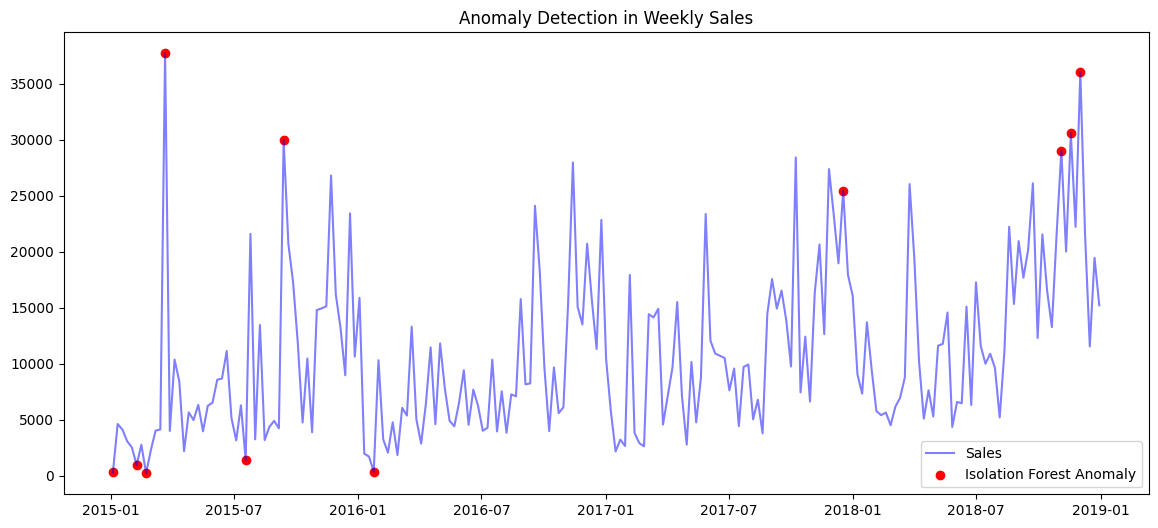

In [ ]:
#task 5
from sklearn.ensemble import IsolationForest

# 1. Prepare Weekly Data
# 'Order Date' is already the index, so remove 'on="Order Date"'
weekly_df = data_set.resample('W')['Sales'].sum().to_frame()
weekly_df['Sales_Value'] = weekly_df['Sales']

# 2. Isolation Forest
# contamination='auto' allows the model to estimate the proportion of outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_df['iso_anomaly'] = iso_forest.fit_predict(weekly_df[['Sales_Value']])
# -1 indicates an anomaly

# 3. Z-Score Detection
# Using a rolling window of 12 weeks to determine the "expected" range
rolling_mean = weekly_df['Sales_Value'].rolling(window=12).mean()
rolling_std = weekly_df['Sales_Value'].rolling(window=12).std()

weekly_df['z_score'] = (weekly_df['Sales_Value'] - rolling_mean) / rolling_std
weekly_df['z_anomaly'] = np.where(np.abs(weekly_df['z_score']) > 2, -1, 1)

# 4. Plotting
plt.figure(figsize=(14, 6))
plt.plot(weekly_df.index, weekly_df['Sales_Value'], label='Sales', color='blue', alpha=0.5)

# Highlight Isolation Forest anomalies
anomalies = weekly_df[weekly_df['iso_anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['Sales_Value'], color='red', label='Isolation Forest Anomaly')

plt.title('Anomaly Detection in Weekly Sales')
plt.legend()
plt.show()

In [ ]:
# Calculate features
subcat_data = data_set.groupby('Sub-Category').agg({
    'Sales': ['sum', 'std'],
    'Order ID': 'count'
})

# Calculate custom features
# subcat_data['Growth_Rate'] = # ... calculate YoY % change
subcat_data['Volatility'] = subcat_data['Sales']['std'] / subcat_data['Sales']['sum']

Text(0.5, 1.0, 'Elbow Method')

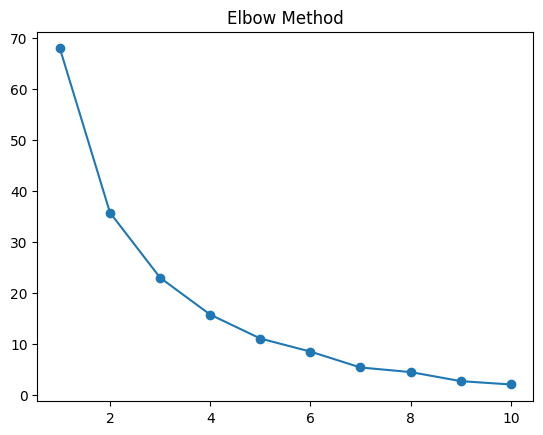

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_data = scaler.fit_transform(subcat_data)

# Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method') # Look for the "bend"

Text(0.5, 1.0, 'Sub-Category Clusters')

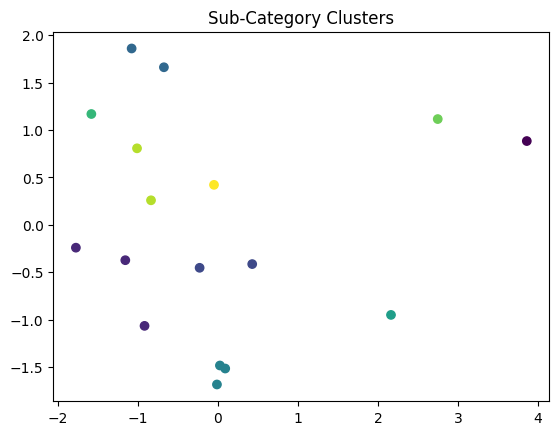

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

plt.scatter(components[:,0], components[:,1], c=kmeans.labels_)
plt.title('Sub-Category Clusters')

In [ ]:
Cluster Label,Stocking Strategy
"High Volume, Stable","Continuous Replenishment: Use Just-in-Time (JIT) delivery. Keep low safety stock; these are your ""bread and butter"" items."
"Low Volume, High Volatility",Make-to-Order / Dropship: Avoid holding these in inventory. They are unpredictable and tie up cash flow.
Growing Demand,Strategic Buffering: Aggressively increase stock levels. Prioritize these for warehouse space and marketing budget.
Declining Demand,Liquidation/Exit: Minimize stock. Stop purchasing; clear out existing inventory through clearance promotions to reclaim capital.

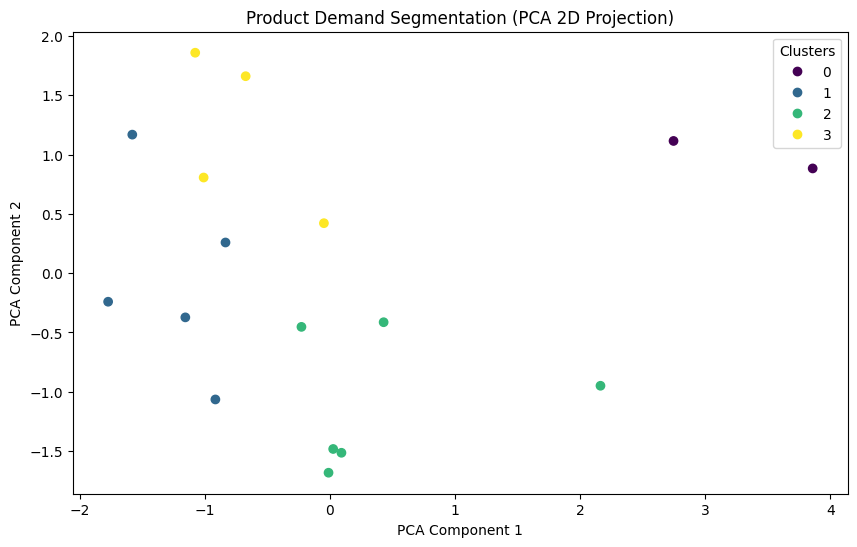

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Flatten MultiIndex columns to single-level strings
# This handles columns like ('Sales', 'sum') becoming 'Sales_sum' and ensures consistency.
if isinstance(subcat_data.columns, pd.MultiIndex):
    subcat_data.columns = ['_'.join(col).strip('_') for col in subcat_data.columns.values]

# 1. Prepare features (subcat_data must be a DataFrame indexed by Sub-Category)
# The 'Profit', 'Quantity', and 'Growth_Rate' columns do not exist in subcat_data.
# We will use the available features:
features = ['Sales_sum', 'Sales_std', 'Order ID_count', 'Volatility']

X = subcat_data[features].fillna(0)

# 2. Scale the data (Mandatory for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Added n_init for modern KMeans
subcat_data['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Reduce to 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=subcat_data['Cluster'], cmap='viridis')
plt.title('Product Demand Segmentation (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [ ]:
%%writefile app.py

Writing app.py


In [ ]:
# 1. Install the localtunnel bridge tool
!npm install -g localtunnel

# 2. Print your unique safety password numbers
import urllib
print("Your tunnel password is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# 3. Start the dashboard server and open the connection bridge
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 1s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸Your tunnel password is: 34.106.111.119
/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴your url is: https://fancy-symbols-watch.loca.lt


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
plotly
scikit-learn
statsmodels
prophet
xgboost